In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
df=pd.read_csv("Iris.csv")

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df = df.drop("Id", axis=1)

In [7]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [8]:
encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

In [9]:
df["Species"].value_counts()

,count
Species,
0,50
1,50
2,50


In [10]:
X = df.drop("Species", axis=1)

y = df["Species"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax")
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4583 - loss: 1.2054 - val_accuracy: 0.5000 - val_loss: 1.0876
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4792 - loss: 1.1099 - val_accuracy: 0.5417 - val_loss: 1.0141
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5104 - loss: 1.0240 - val_accuracy: 0.5417 - val_loss: 0.9456
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5625 - loss: 0.9473 - val_accuracy: 0.6250 - val_loss: 0.8863
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6042 - loss: 0.8789 - val_accuracy: 0.6250 - val_loss: 0.8327
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6771 - loss: 0.8171 - val_accuracy: 0.7083 - val_loss: 0.7834
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7812 - loss: 0.7609 - val_accuracy: 0.7500 - val_loss: 0.7397
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8125 - loss: 0.7103 - val_accuracy: 0.7500 - val_loss: 0.7019


In [18]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.33370882272720337
Test Accuracy: 0.8333333134651184


In [19]:
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 0.8333
Final Test Accuracy: 83.33%


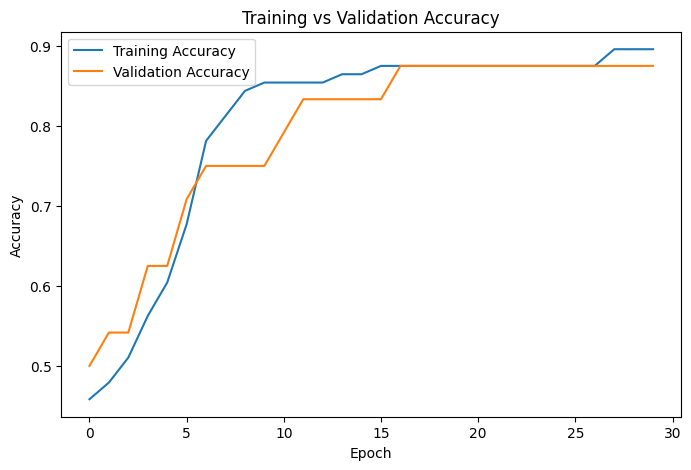

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

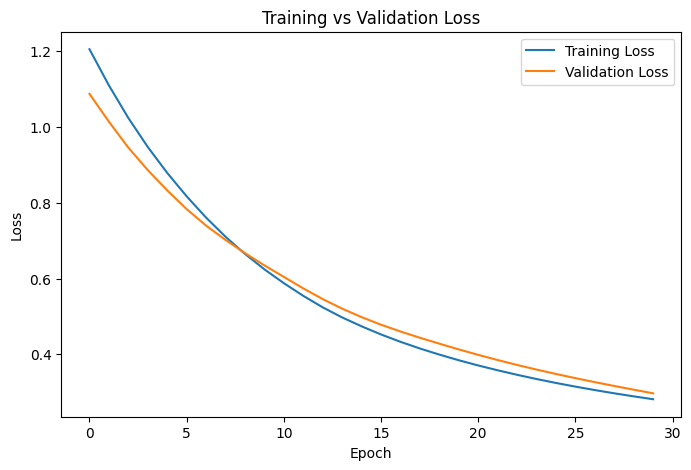

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [22]:
pred_probabilities = model.predict(X_test_scaled)

predictions = np.argmax(
    pred_probabilities,
    axis=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


In [23]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,2
6,0,0
7,0,0
8,2,2
9,1,1


In [24]:
comparison["Actual Species"] = encoder.inverse_transform(
    comparison["Actual"]
)

comparison["Predicted Species"] = encoder.inverse_transform(
    comparison["Predicted"]
)

comparison.head(10)

,Actual,Predicted,Actual Species,Predicted Species
0,0,0,Iris-setosa,Iris-setosa
1,2,2,Iris-virginica,Iris-virginica
2,1,1,Iris-versicolor,Iris-versicolor
3,1,1,Iris-versicolor,Iris-versicolor
4,0,0,Iris-setosa,Iris-setosa
5,1,2,Iris-versicolor,Iris-virginica
6,0,0,Iris-setosa,Iris-setosa
7,0,0,Iris-setosa,Iris-setosa
8,2,2,Iris-virginica,Iris-virginica
9,1,1,Iris-versicolor,Iris-versicolor


In [25]:
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 83.33%
